# 09 — VAR (Vector Autoregression)

VAR models all variables as jointly endogenous — each variable is regressed on its own
lags and the lags of every other variable. Unlike ARIMAX (where gold/USD are exogenous
inputs), VAR treats silver, gold, USD, copper and S&P500 returns as a system and lets
the data decide how they influence each other.

Key outputs beyond forecasting:
- **Lag order selection** (AIC/BIC)
- **Granger causality tests** — formally tests whether other variables help predict silver
- **Impulse response functions** — how a shock to one variable propagates through the system
- **Walk-forward forecast** with same DA/WDA metrics as other notebooks

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

## 1. Load and aggregate to weekly

In [11]:
train = pd.read_csv('../../data/processed/train.csv', index_col=0, parse_dates=True)
val   = pd.read_csv('../../data/processed/val.csv',   index_col=0, parse_dates=True)
test  = pd.read_csv('../../data/processed/test.csv',  index_col=0, parse_dates=True)

# VAR endogenous variables — all treated symmetrically
COLS = ['silver_return', 'gold_return', 'usd_return', 'copper_return', 'sp500_return']

def to_weekly(df):
    return df[COLS].resample('W-FRI').sum().dropna()

train_w = to_weekly(train)
val_w   = to_weekly(val)
test_w  = to_weekly(test)

all_w   = pd.concat([train_w, val_w, test_w])
n_train = len(train_w) + len(val_w)

print(f'Weekly obs — train+val: {n_train}, test: {len(test_w)}')
all_w.head()

Weekly obs — train+val: 417, test: 175


,silver_return,gold_return,usd_return,copper_return,sp500_return
Date,,,,,
2015-01-09,0.040603,0.024980,0.009398,-0.017055,-0.006527
2015-01-16,0.079338,0.048869,0.006289,-0.050153,-0.012495
2015-01-23,0.030261,0.012220,0.026452,-0.044889,0.015917
2015-01-30,-0.061582,-0.010968,-0.002107,-0.003751,-0.028088
2015-02-06,-0.030354,-0.035508,-0.001055,0.029236,0.029865


## 2. Lag order selection

Fit VAR on the training set and select lag order by AIC and BIC.
BIC penalises extra lags more heavily — usually gives a more parsimonious model.

In [12]:
model_sel = VAR(all_w.iloc[:n_train])
lag_results = model_sel.select_order(maxlags=10)
print(lag_results.summary())

best_lag_aic = lag_results.aic
best_lag_bic = lag_results.bic
print(f'\nSelected lag — AIC: {best_lag_aic},  BIC: {best_lag_bic}')
LAG = max(best_lag_bic, 1)  # use BIC; floor at 1
print(f'Using lag: {LAG}')

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0      -39.85*     -39.80*  4.955e-18*     -39.83*
1       -39.84      -39.55   4.978e-18      -39.72
2       -39.79      -39.25   5.224e-18      -39.58
3       -39.77      -38.98   5.344e-18      -39.46
4       -39.72      -38.69   5.605e-18      -39.31
5       -39.72      -38.44   5.608e-18      -39.22
6       -39.70      -38.17   5.742e-18      -39.10
7       -39.65      -37.87   6.069e-18      -38.94
8       -39.57      -37.56   6.524e-18      -38.78
9       -39.54      -37.27   6.770e-18      -38.64
10      -39.47      -36.96   7.238e-18      -38.48
--------------------------------------------------

Selected lag — AIC: 0,  BIC: 0
Using lag: 1


## 3. Granger causality tests

Tests whether lagged values of each variable significantly improve forecasts of silver
beyond silver's own history. A significant result (p < 0.05) means the variable
Granger-causes silver — it adds predictive information.

Note: Granger causality is about predictability, not economic causality.

In [13]:
train_data = all_w.iloc[:n_train]

print(f'Granger causality → silver_return (maxlags={LAG}):')
print('-' * 55)
for col in [c for c in COLS if c != 'silver_return']:
    # grangercausalitytests needs [target, predictor] order
    gc_data = train_data[['silver_return', col]].dropna()
    res = grangercausalitytests(gc_data, maxlag=LAG, verbose=False)
    # Use F-test p-value at the selected lag
    p = res[LAG][0]['ssr_ftest'][1]
    sig = '*' if p < 0.05 else ''
    print(f'  {col:<20}  p={p:.4f}  {sig}')
print('\n* p < 0.05 — variable Granger-causes silver')

Granger causality → silver_return (maxlags=1):
-------------------------------------------------------
  gold_return           p=0.4432  
  usd_return            p=0.4602  
  copper_return         p=0.4771  
  sp500_return          p=0.2074  

* p < 0.05 — variable Granger-causes silver


## 4. Impulse response functions

How does a one-standard-deviation shock to each variable affect silver return over the
next 10 weeks? Shaded area = 95% confidence interval.

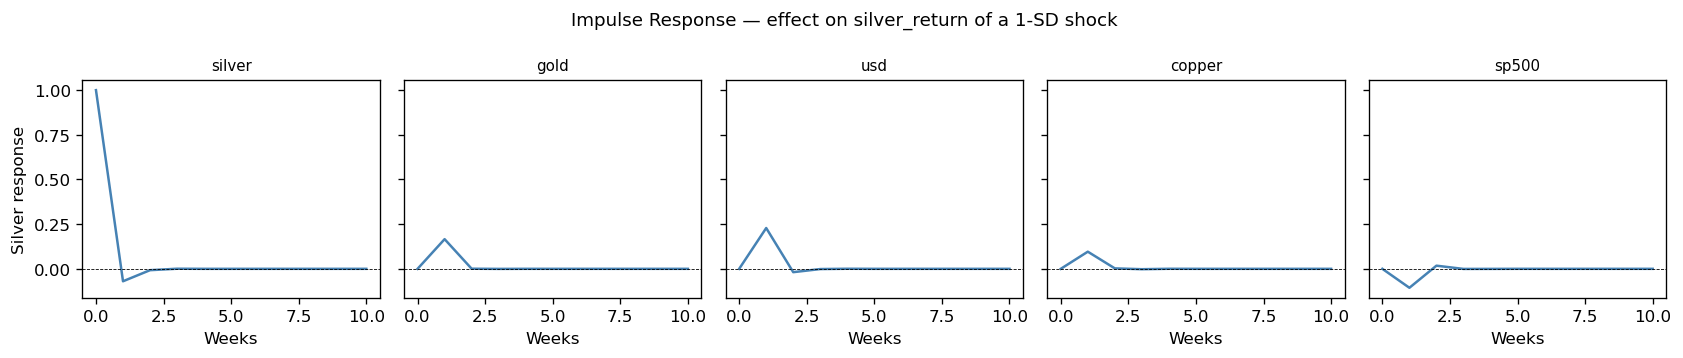

In [14]:
fitted = VAR(train_data).fit(LAG)
irf = fitted.irf(periods=10)

silver_idx = COLS.index('silver_return')
fig, axes = plt.subplots(1, len(COLS), figsize=(14, 3), sharey=True)

for j, col in enumerate(COLS):
    # Response of silver (row silver_idx) to shock in col (column j)
    response = irf.irfs[:, silver_idx, j]
    lower    = irf.cum_effect_stderr(orth=False)  # skip — use plot method instead
    axes[j].plot(response, color='steelblue', lw=1.5)
    axes[j].axhline(0, color='black', lw=0.5, ls='--')
    axes[j].set_title(col.replace('_return', ''), fontsize=9)
    axes[j].set_xlabel('Weeks')

axes[0].set_ylabel('Silver response')
fig.suptitle('Impulse Response — effect on silver_return of a 1-SD shock', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Walk-forward forecast

At each test week $t$ we refit VAR on all weeks before $t$ (expanding window) and
predict one step ahead. Only the silver equation's forecast is evaluated.

In [15]:
WINDOW = 100  # rolling window size — set to None for expanding

silver_col = COLS.index('silver_return')

def var_walk_forward(all_w, n_train, lag, window=None):
    """window=None → expanding; window=N → rolling (last N weeks)."""
    preds = np.full(len(all_w) - n_train, np.nan)
    for i, t in enumerate(range(n_train, len(all_w))):
        start   = max(0, t - window) if window else 0
        history = all_w.iloc[start:t]
        try:
            model = VAR(history).fit(lag)
            fc    = model.forecast(history.values[-lag:], steps=1)
            preds[i] = fc[0, silver_col]
        except Exception:
            pass
    return preds

print('Running VAR — expanding window...')
preds_exp = var_walk_forward(all_w, n_train, LAG, window=None)
print('Running VAR — rolling window (100 weeks)...')
preds_rol = var_walk_forward(all_w, n_train, LAG, window=WINDOW)
print(f'Expanding: {(~np.isnan(preds_exp)).sum()} forecasts')
print(f'Rolling:   {(~np.isnan(preds_rol)).sum()} forecasts')
preds = preds_exp  # default used downstream

Running VAR — expanding window...
Running VAR — rolling window (100 weeks)...
Expanding: 175 forecasts
Rolling:   175 forecasts


## 6. Evaluate

In [ ]:
y_test     = all_w['silver_return'].iloc[n_train:].values
test_index = all_w.index[n_train:]

def evaluate(name, y_true, y_pred):
    mask = ~np.isnan(y_pred) & ~np.isnan(y_true)
    if mask.sum() == 0:
        print(f'{name:40s}  No valid predictions')
        return None
    y_t, y_p = y_true[mask], y_pred[mask]
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae  = mean_absolute_error(y_t, y_p)
    da   = np.mean(np.sign(y_t) == np.sign(y_p))
    wda  = np.sum(np.abs(y_t) * (np.sign(y_t) == np.sign(y_p))) / np.sum(np.abs(y_t))
    print(f'{name:40s}  RMSE={rmse:.5f}  MAE={mae:.5f}  DA={da:.3f}  WDA={wda:.3f}')
    print()
    return {'model': name, 'rmse': rmse, 'mae': mae, 'dir_acc': da, 'wda': wda}

naive_pred = all_w['silver_return'].iloc[n_train-1:-1].values

metrics = []
metrics.append(evaluate('Naive (t-1 week)', y_test[1:], naive_pred[1:]))
metrics.append(evaluate(f'VAR({LAG}) expanding',      y_test, preds_exp))
metrics.append(evaluate(f'VAR({LAG}) rolling (100w)', y_test, preds_rol))

metrics_df = pd.DataFrame([m for m in metrics if m is not None])
metrics_df.to_csv('../../data/processed/metrics_var.csv', index=False)
metrics_df

Naive (t-1 week)                          RMSE=0.07584  MAE=0.05386  DA=0.494  WDA=0.491
VAR(1) expanding                          RMSE=0.05220  MAE=0.03758  DA=0.503  WDA=0.498
VAR(1) rolling (100w)                     RMSE=0.05341  MAE=0.03898  DA=0.417  WDA=0.439


,model,rmse,mae,dir_acc,wda
0,Naive (t-1 week),0.075840,0.053865,0.494253,0.491093
1,VAR(1) expanding,0.052202,0.037576,0.502857,0.497707
2,VAR(1) rolling (100w),0.053413,0.038980,0.417143,0.438890


## 7. Predicted vs actual

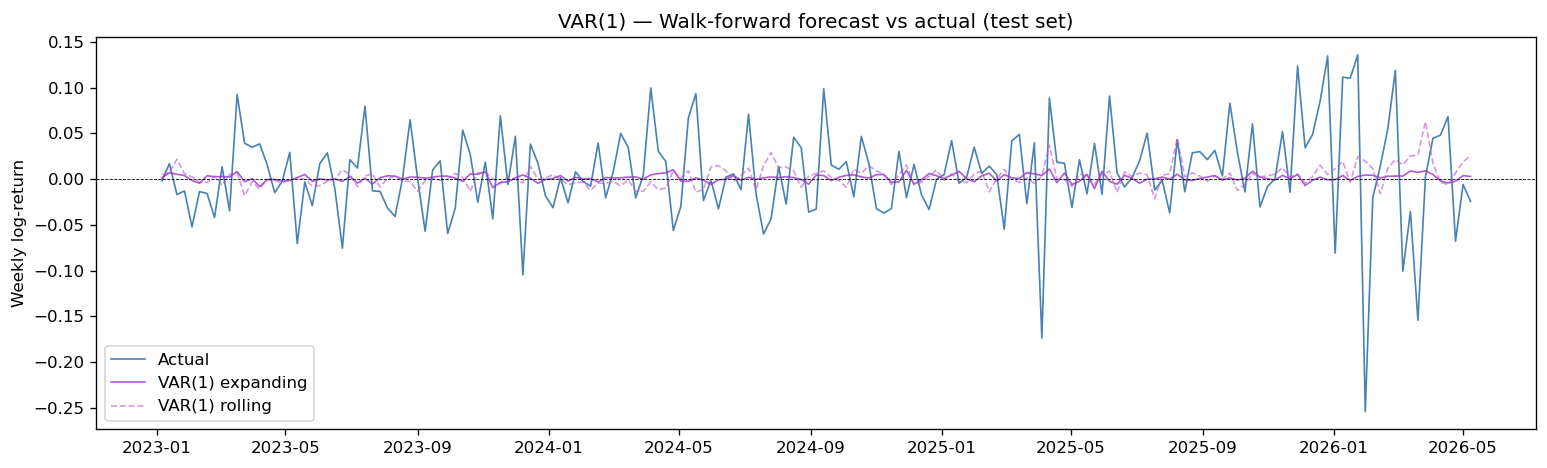

In [17]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test_index, y_test, lw=1,   label='Actual',       color='steelblue')
ax.plot(test_index, preds_exp, lw=1, label=f'VAR({LAG}) expanding', color='darkorchid', alpha=0.8)
ax.plot(test_index, preds_rol, lw=1, label=f'VAR({LAG}) rolling',   color='mediumorchid', alpha=0.6, ls='--')
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.set_title(f'VAR({LAG}) — Walk-forward forecast vs actual (test set)')
ax.set_ylabel('Weekly log-return')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Sentiment comparison

Adds lagged Reddit and news sentiment as endogenous variables in the VAR system.
Lag order is re-selected on each augmented dataset. Silver forecasts are compared
across three specifications: no sentiment, Reddit + News, news only (GDELT).

In [ ]:
import os

sent_path = '../../data/processed/daily_sentiment.csv'
if not os.path.exists(sent_path):
    print('daily_sentiment.csv not found — run 06_sentiment.ipynb first.')
else:
    sentiment = pd.read_csv(sent_path, index_col=0, parse_dates=True)
    sent_w = sentiment[["reddit_sentiment", "news_sentiment"]].resample("W-FRI").mean()

    def var_sentiment_run(all_w, n_train, sent_cols, label):
        # Merge sentiment into the VAR system (endogenous)
        sent_aligned = sent_w[sent_cols].reindex(all_w.index).ffill().fillna(0)
        all_aug = pd.concat([all_w, sent_aligned], axis=1).dropna()

        # Re-select lag order on training data
        try:
            lag_sel = VAR(all_aug.iloc[:n_train]).select_order(maxlags=8)
            lag = max(lag_sel.bic, 1)
        except Exception:
            lag = LAG

        silver_col_aug = all_aug.columns.tolist().index("silver_return")

        preds_exp = np.full(len(all_aug) - n_train, np.nan)
        preds_rol = np.full(len(all_aug) - n_train, np.nan)

        for i, t in enumerate(range(n_train, len(all_aug))):
            for window, out in [(None, preds_exp), (100, preds_rol)]:
                start   = max(0, t - window) if window else 0
                history = all_aug.iloc[start:t]
                try:
                    m  = VAR(history).fit(lag)
                    fc = m.forecast(history.values[-lag:], steps=1)
                    out[i] = fc[0, silver_col_aug]
                except Exception:
                    pass

        y_t = all_aug["silver_return"].iloc[n_train:].values
        print("--- {} ---".format(label))
        r_exp = evaluate("{} expanding".format(label),      y_t, preds_exp)
        r_rol = evaluate("{} rolling (100w)".format(label), y_t, preds_rol)
        return r_exp, r_rol

    print("Running VAR + Reddit + News...")
    var_sentiment_run(all_w, n_train, ["reddit_sentiment", "news_sentiment"], "Reddit+News")
    print()

    print("Running VAR + Reddit only...")
    var_sentiment_run(all_w, n_train, ["reddit_sentiment"], "Reddit only")
    print()

    print("Running VAR + News only (GDELT)...")
    var_sentiment_run(all_w, n_train, ["news_sentiment"], "News only")
    print()

    print("Baseline (no sentiment) for reference:")
    evaluate("VAR expanding (no sentiment)",      y_test, preds_exp)
    evaluate("VAR rolling 100w (no sentiment)",   y_test, preds_rol)


Running VAR + Reddit + News...
--- Reddit+News ---
Reddit+News expanding                     RMSE=0.05215  MAE=0.03740  DA=0.497  WDA=0.520
Reddit+News rolling (100w)                RMSE=0.05353  MAE=0.03872  DA=0.491  WDA=0.552
Running VAR + Reddit only...
--- Reddit only ---
Reddit only expanding                     RMSE=0.05230  MAE=0.03759  DA=0.491  WDA=0.519
Reddit only rolling (100w)                RMSE=0.05360  MAE=0.03890  DA=0.434  WDA=0.438
Running VAR + News only (GDELT)...
--- News only ---
News only expanding                       RMSE=0.05205  MAE=0.03739  DA=0.503  WDA=0.538
News only rolling (100w)                  RMSE=0.05342  MAE=0.03881  DA=0.480  WDA=0.496

Baseline (no sentiment) for reference:
VAR expanding (no sentiment)              RMSE=0.05220  MAE=0.03758  DA=0.503  WDA=0.498
VAR rolling 100w (no sentiment)           RMSE=0.05341  MAE=0.03898  DA=0.417  WDA=0.439
